# Глубокое обучение 


## Тема 5. Нормализующие потоки.  Моделирование изображений 🌀 


Рассмотрим подробнее более сложные и глубокие потоки нормализации. Самым популярным в настоящее время применением потоков глубокой нормализации является моделирование наборов данных изображений. Что касается других генеративных моделей, изображения — хорошая область для начала работы, потому что (1) CNN широко изучены и существуют сильные модели, (2) изображения являются многомерными и сложными и (3) изображения представляют собой дискретные целые числа. Обратите внимание, что нормализующие потоки обычно содержат много параметров и, следовательно, требуют больших вычислительных затрат. Мы будем использовать относительно простые и неглубокие потоки, чтобы сэкономить вычислительные затраты и позволить запускать ноутбук на ЦП, но имейте в виду, что простой способ улучшить показатели изучаемых здесь потоков — сделать нейронные сети глубже.

В этом блокноте мы используем [PyTorch Lightning](https://pytorch-lightning.readthedocs.io/en/latest/). Первая ячейка импортирует наши обычные библиотеки.

In [1]:
## Standard libraries
import os
import math
import time
import numpy as np 

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline 
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgb
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.reset_orig()

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # no PyTorch Lightning installed 
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    LearningRateMonitor, ModelCheckpoint
)
# Path to the folder where the datasets are/should be downloaded 
DATASET_PATH = "./data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "./saved_models"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device_str = \
    "cuda" if torch.cuda.is_available() else \
    "mps" if torch.backends.mps.is_available() else \
    "cpu"
device = torch.device(device_str)

print("Using device", device)

Seed set to 42


Using device mps


В этом блокноте мы будем использовать набор данных MNIST. MNIST, несмотря на свою простоту, представляет собой проблему для небольших генеративных моделей, поскольку требует глобального понимания изображения. В то же время мы можем легко судить, происходят ли сгенерированные изображения из того же распределения, что и набор данных (т.е. представляют собой реальные цифры), или нет.

Чтобы лучше справиться с дискретной природой изображений, мы преобразуем их из диапазона 0–1 в диапазон 0–255 как целые числа.

Будем использовать несколько предварительно обученных моделей. 

In [2]:
# Convert images from 0-1 to 0-255 (integers)
def discretize(sample):
    return (sample * 255).to(torch.int32)

# Transformations applied on each image 
transform = transforms.Compose([
    transforms.ToTensor(),
    discretize
])

# Loading the training dataset. We need to split it 
# into a training and validation part
train_dataset = MNIST(
    root=DATASET_PATH, train=True, transform=transform, download=True
)
pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(
    train_dataset, [50000, 10000]
)

# Loading the test set
test_set = MNIST(
    root=DATASET_PATH, train=False, transform=transform, download=True
)

# We define a set of data loaders that we can use for various 
# purposes later. Note that for actually training a model, 
# we will use different data loaders with a lower batch size.
train_loader = data.DataLoader(
    train_set, batch_size=256, shuffle=False, drop_last=False
)
val_loader = data.DataLoader(
    val_set, batch_size=64, shuffle=False, 
    drop_last=False, num_workers=4
)
test_loader = data.DataLoader(
    test_set, batch_size=64, shuffle=False, 
    drop_last=False, num_workers=4
)

Seed set to 42


Кроме того, ниже мы определим функцию для  визуализации изображений/образцов. Некоторые обучающие изображения набора данных MNIST показаны ниже.

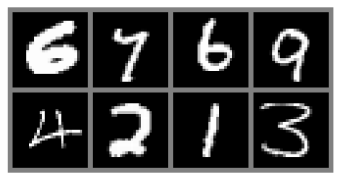

In [3]:
def show_imgs(imgs, title=None, row_size=4):
    # Form a grid of pictures (we use max. 8 columns)
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    is_int = imgs.dtype==torch.int32 if isinstance(imgs, torch.Tensor) else imgs[0].dtype==torch.int32
    nrow = min(num_imgs, row_size)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128 if is_int else 0.5)
    np_imgs = imgs.cpu().numpy()
    # Plot the grid
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    if title is not None:
        plt.title(title)
    plt.show()
    plt.close()

show_imgs([train_set[i][0] for i in range(8)])

## Нормализующие потоки как генеративная модель

Ранее мы рассматривали вариационные автоэнкодеры (VAE) и генеративно-состязательные сети (GAN) в качестве примера генеративных моделей. Однако ни одна из этим моделей явно не изучает функцию плотности вероятности $p(x)$ реальных входных данных. В то время как VAE моделируют нижнюю границу, GAN предоставляют нам механизм выборки для генерации новых данных, не предлагая оценки вероятности. Генеративная модель, которую мы здесь рассмотрим, называемая нормализацией потоков, фактически моделирует истинное распределение данных $p(x)$ и предоставляет нам точную оценку правдоподобия. Ниже мы можем визуально сравнить VAE, GAN и нормализующие потоки.

<!-- center width="100%"><img src="comparison_GAN_VAE_NF.png" width="600px"></center-->

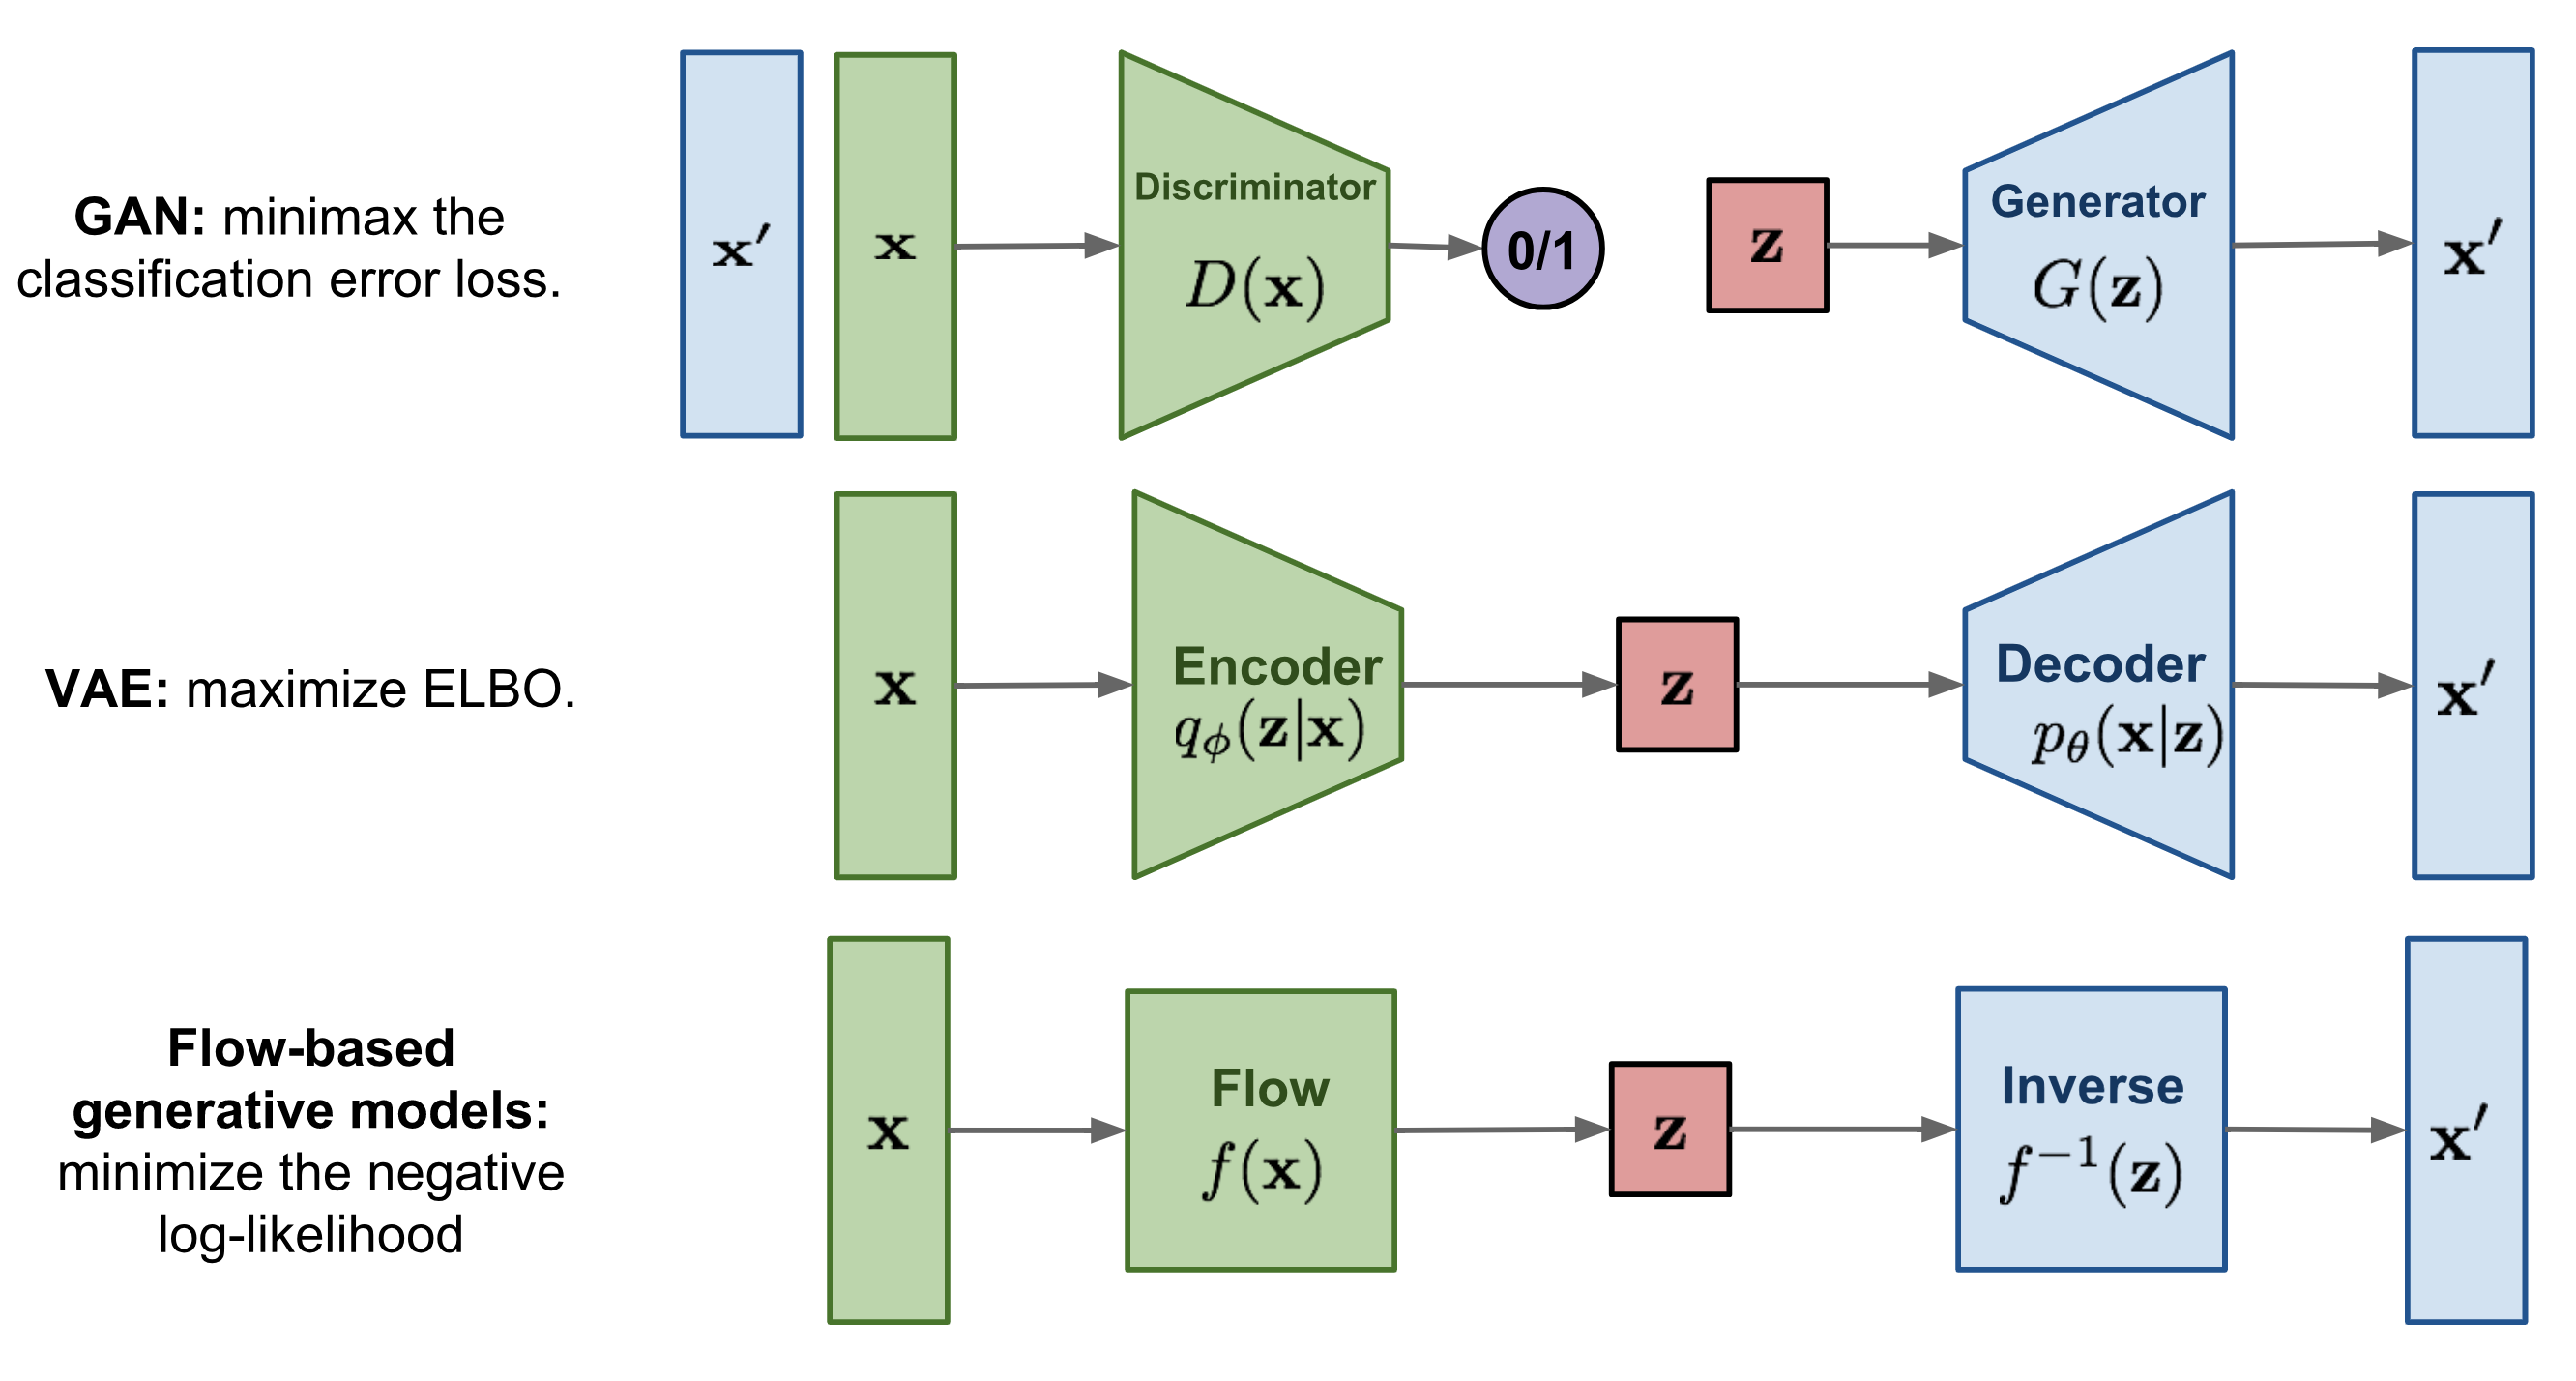

Основное отличие от VAE состоит в том, что потоки используют *обратимые* функции $f$ для отображения входных данных $x$ в скрытое представление $z$. Чтобы это реализовать, $z$ должен иметь ту же форму, что и $x$. В этом отличие от VAE, где $z$ обычно имеет гораздо меньшую размерность, чем исходные входные данные. Однако обратимое отображение также означает, что для каждой точки данных $x$ у нас есть соответствующее скрытое представление $z$, которое позволяет нам выполнять реконструкцию без потерь (от $z$ до $x$). В приведенной выше визуализации это означает, что $x=x'$ для потоков, независимо от того, какую обратимую функцию $f$ и вход $x$ мы выберем.

Тем не менее, как нормализующие потоки моделируют плотность вероятности с обратимой функцией? Ответом на этот вопрос является правило замены переменных. В частности, учитывая априорную плотность $p_z(z)$ (например, гауссову) и обратимую функцию $f$, мы можем определить $p_x(x)$ следующим образом:

$$
\begin{split}
    \int p_x(x) dx & = \int p_z(z) dz = 1 \hspace{1cm}\text{(по определению вероятностного распределения)}\\
    \Leftrightarrow p_x(x) & = p_z(z) \left|\frac{dz}{dx}\right| = p_z(f(x)) \left|\frac{df(x)}{dx}\right|
\end{split}
$$

Следовательно, чтобы определить вероятность $x$, нам нужно только определить его вероятность в скрытом пространстве и получить производную функции $f$. Обратите внимание, что это одномерное распределение, и функция $f$ должна быть обратимой и гладкой. В многомерном случае производная становится якобианом, определитель которого нам нужно вычислить. Поскольку мы обычно используем логарифмическое правдоподобие в качестве цели, запишем многомерное выражение с логарифмами ниже:

$$
\log p_x(\mathbf{x}) = \log p_z(f(\mathbf{x})) + \log{} \left|\det \frac{df(\mathbf{x})}{d\mathbf{x}}\right|
$$

Хотя теперь мы знаем, как нормализующий поток получает свое правдоподобие, может быть неясно, что делает нормализующий поток на интуитивном уровне. Для этого нам следует взглянуть на поток с обратной точки зрения, начиная с априорной плотности вероятности $p_z(z)$. Если мы применим к нему обратимую функцию, то мы эффективно «преобразуем» его плотность вероятности. Например, если $f^{-1}(z)=z+1$, мы сдвигаем плотность на единицу, оставаясь при этом действительным распределением вероятностей и сохраняя  обратимость. Мы также можем применить более сложные преобразования, например масштабирование: $f^{-1}(z)=2z+1$, но здесь вы можете увидеть разницу. При масштабировании вы также меняете объем плотности вероятности, как, например, при равномерных распределениях (рисунок предоставлен [Эриком Джангом](https://blog.evjang.com/2018/01/nf1.html)):

<!--center width="100%"><img src="uniform_flow.png" width="300px"></center-->
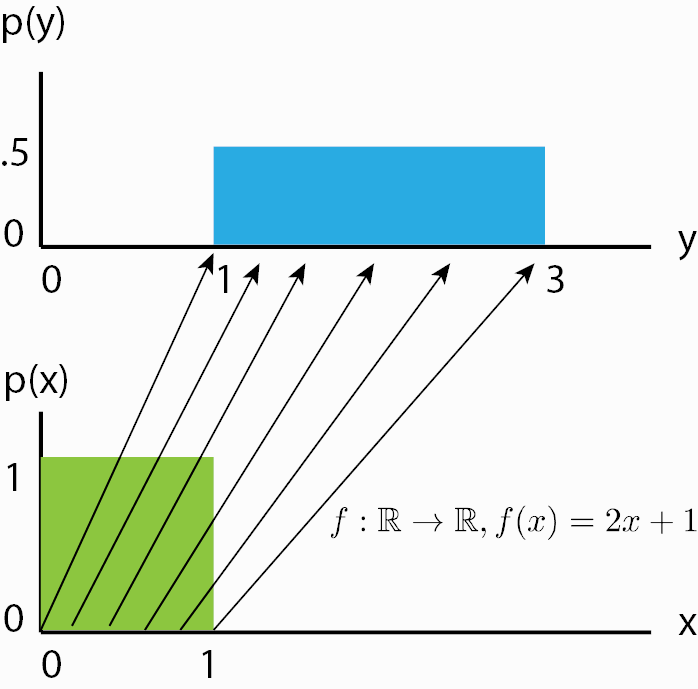

Вы можете видеть, что после масштабирования высота $p(y)$ должна быть ниже, чем $p(x)$. Это изменение объема представляет собой $\left|\frac{df(x)}{dx}\right|$ в нашем уравнении выше и гарантирует, что даже после масштабирования у нас все еще будет правильное распределение вероятностей. Мы можем продолжать усложнять нашу функцию $f$. Однако чем сложнее становится функция $f$, тем труднее будет найти обратную к ней $f^{-1}$ и вычислить логарифм определителя якобиана $\log{} \left|\det \frac{df(\mathbf{x})}{d\mathbf{x}}\right|$. Более простой способ состоит в том, чтобы сложить несколько обратимых функций $f_{1,...,K}$ друг за другом, поскольку все вместе они по-прежнему представляют одну обратимую функцию. Используя несколько обучаемых обратимых функций, нормализующий поток пытается медленно преобразовать $p_z(z)$ в более сложное распределение, которое в конечном итоге должно быть $p_x(x)$. Визуализируем идею ниже
(изображение предоставлено - [Лилиан Венг](https://lilianweng.github.io/lil-log/2018/10/13/flow-based-deep-generative-models.html)):

<!--center width="100%"><img src="normalizing_flow_layout.png" width="700px"></center-->

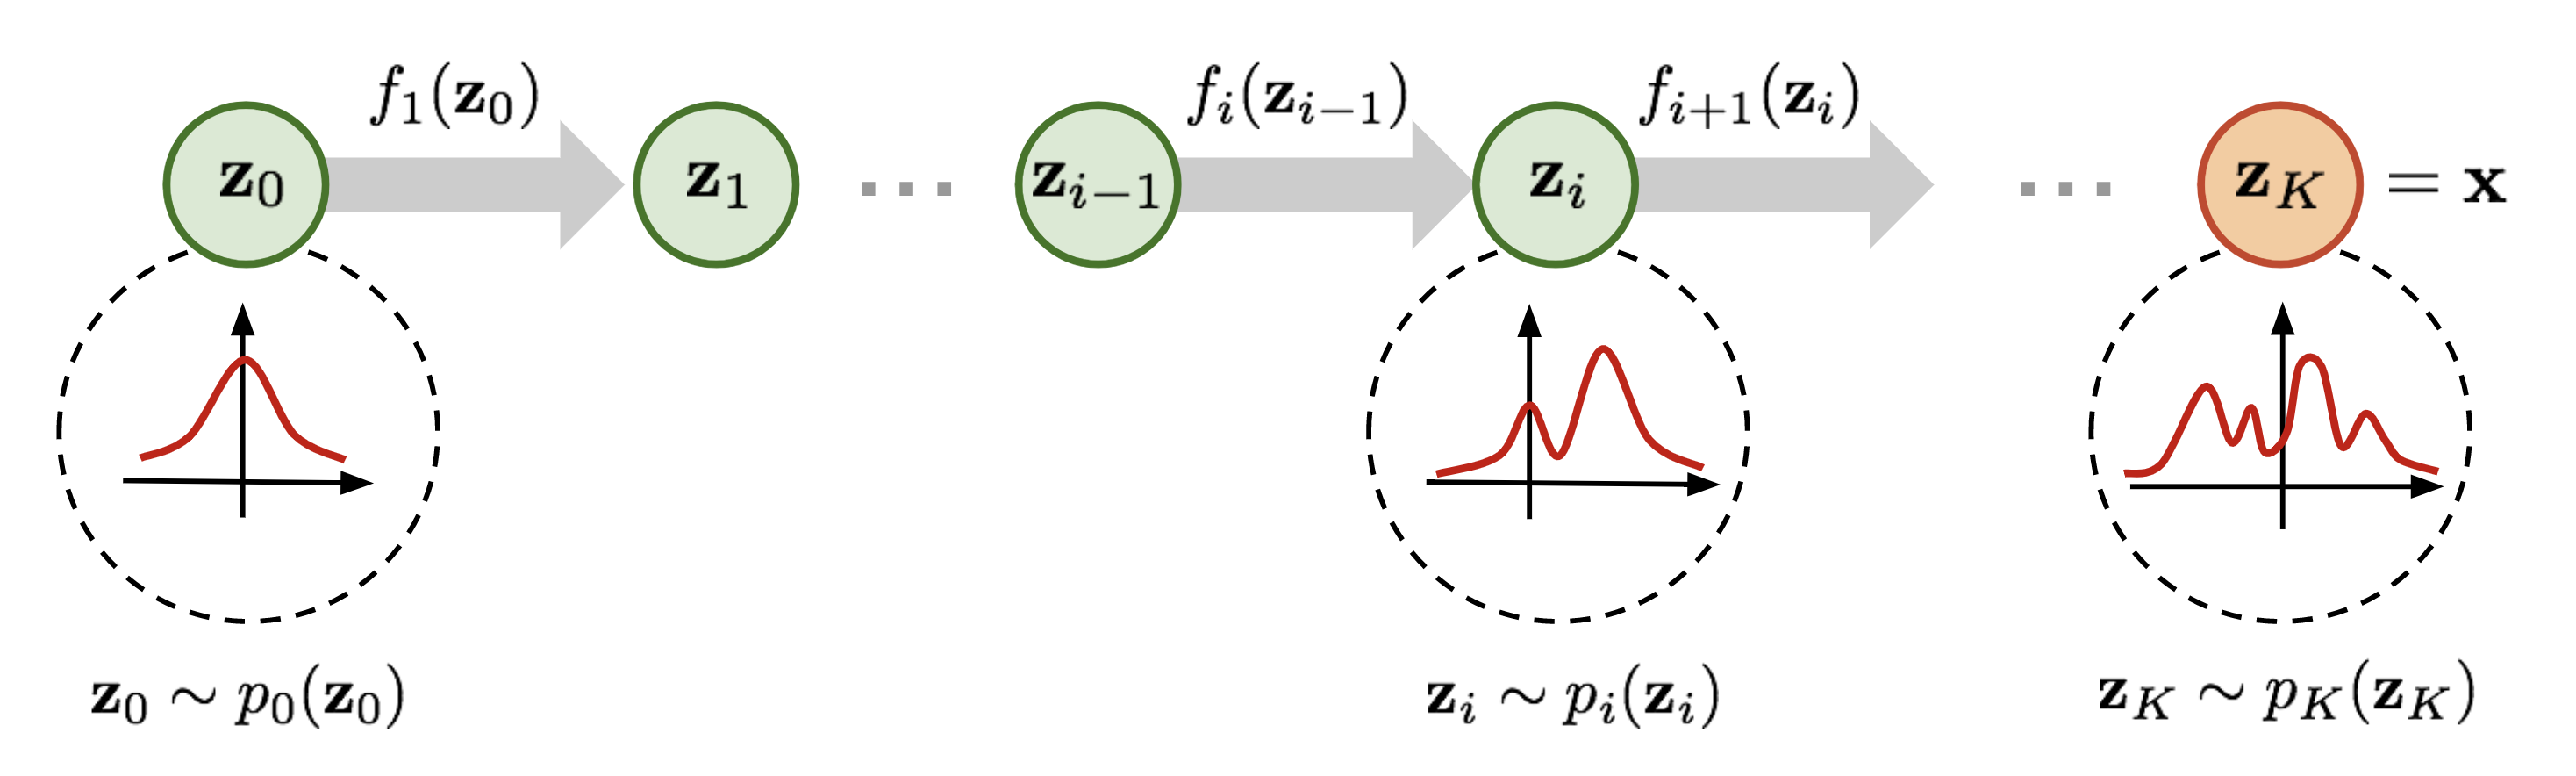

Начиная с распределения $z_0$, которое соответствует априорному гауссовому распределению, мы последовательно применяем обратимые функции $f_1,f_2,...,f_K$, пока распределение $z_K$ не будет представлять собой распределение $x$. Обратите внимание, что на рисунке выше функции $f$ представляют собой инвертированную функцию из $f$, которую мы рассматривали раньше (здесь: $f:Z\to X$, выше: $f:X\to Z$). Это просто другое обозначение, которое не влияет на фактическую схему потока, поскольку все функции $f$ в любом случае должны быть обратимыми. Когда мы оцениваем логарифмическую правдоподобие точки данных $x$, как в приведенных выше уравнениях, мы запускаем потоки в направлении, противоположном тому, которое визуализировалось выше. Было предложено несколько слоев потока, которые используют нейронную сеть в качестве обучаемых параметров, таких как плоский и радиальный поток. Однако здесь мы сосредоточимся на потоках, которые обычно используются при моделировании изображений, и обсудим их в оставшейся части блокнота вместе с подробностями обучения нормализующего потока.


## Нормализующие потоки для изображений

Чтобы познакомиться применением нормализующих потоков к моделированию изображений, лучше всего обсудить различные элементы потоков вместе с их реализацией. В качестве общей концепции мы хотим построить нормализующий поток, который отображает входное изображение (в данном случае MNIST) в скрытое пространство такого же размера:

<!--center width="100%" style="padding: 10px"><img src="image_to_gaussian.svg" width="450px"></center-->

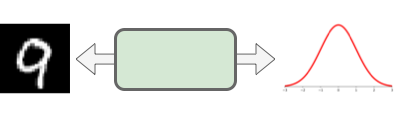

На первом этапе мы реализуем шаблон нормализующего потока в PyTorch Lightning. Во время обучения и валидации нормализующий поток выполняет оценку плотности в прямом направлении. Для этого мы применяем серию преобразований потока к входным данным $x$ и оцениваем вероятность входных данных, определяя вероятность преобразованной точки $z$ с учетом априорных данных и изменение объема, вызванное преобразованиями. В процессе вывода мы можем выполнять как оценку плотности, так и выборку новых точек, инвертируя преобразования потока. Поэтому мы определяем метод `_get_likelihood`, который выполняет оценку плотности, и метод `sample` для генерации новых точек. Методы `training_step`, `validation_step` и `test_step` используют метод `_get_likelihood`.

Стандартной метрикой, используемой в генеративных моделях, и, в частности, в нормализующих потоках, является количество битов на измерение (`bpd`). Показатель `bpd` обоснован с точки зрения теории информации и описывает, сколько битов нам потребуется для кодирования конкретной точки в нашем моделируемом распределении. Чем меньше битов нам нужно, тем вероятнее точка в нашем распределении. Проверяя `bpd` (кол-во битов на измерение) нашего тестового набора данных, мы можем оценить, обобщается ли наша модель на новые точки набора данных и не запомнила ли она обучающий набор данных. Чтобы рассчитать оценку `bpd` (битов на измерение), мы можем использовать отрицательное логарифмическое правдоподобие (NLL) и изменить основание логарифма (поскольку биты являются двоичными, а NLL обычно экспоненциальным):

$$\text{bpd} = \text{nll} \cdot \log_2\left(\exp(1)\right) \cdot \left(\prod d_i\right)^{-1},$$

где $d_1,...,d_K$ — размеры входных данных. Для изображений это высота, ширина и номер канала. Мы делим логарифм правдоподобия на эти дополнительные измерения, чтобы получить метрику, которую можно сравнивать для изображений с разным разрешением. В исходном пространстве изображений точки MNIST имеют оценку бит на измерение, равную 8 (нам требуется 8 бит для кодирования каждого пикселя, поскольку существует 256 возможных значений).

In [4]:
class ImageFlow(pl.LightningModule):
    
    def __init__(self, flows, import_samples=8):
        """
        Inputs:
            flows - A list of flows (each a nn.Module) that should be applied on the images. 
            import_samples - Number of importance samples to use during testing (see explanation below). Can be changed at any time
        """
        super().__init__()
        self.flows = nn.ModuleList(flows)
        self.import_samples = import_samples
        # Create prior distribution for final latent space
        self.prior = torch.distributions.normal.Normal(loc=0.0, scale=1.0)
        # Example input for visualizing the graph
        self.example_input_array = train_set[0][0].unsqueeze(dim=0)

    def forward(self, imgs):
        # The forward function is only used for visualizing the graph
        return self._get_likelihood(imgs)

    def encode(self, imgs):
        # Given a batch of images, return the latent representation z and ldj of the transformations
        z, ldj = imgs, torch.zeros(imgs.shape[0], device=self.device)
        for flow in self.flows:
            z, ldj = flow(z, ldj, reverse=False)
        return z, ldj

    def _get_likelihood(self, imgs, return_ll=False):
        """
        Given a batch of images, return the likelihood of those. 
        If return_ll is True, this function returns the log likelihood of the input.
        Otherwise, the ouptut metric is bits per dimension (scaled negative log likelihood)
        """
        z, ldj = self.encode(imgs)
        log_pz = self.prior.log_prob(z).sum(dim=[1,2,3])
        log_px = ldj + log_pz
        nll = -log_px
        # Calculating bits per dimension
        bpd = nll * np.log2(np.exp(1)) / np.prod(imgs.shape[1:])
        return bpd.mean() if not return_ll else log_px

    @torch.no_grad()
    def sample(self, img_shape, z_init=None):
        """
        Sample a batch of images from the flow.
        """
        # Sample latent representation from prior
        if z_init is None:
            z = self.prior.sample(sample_shape=img_shape).to(device)
        else:
            z = z_init.to(device)
        
        # Transform z to x by inverting the flows
        ldj = torch.zeros(img_shape[0], device=device)
        for flow in reversed(self.flows):
            z, ldj = flow(z, ldj, reverse=True)
        return z

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        # An scheduler is optional, but can help in flows to get the last bpd improvement
        scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        # Normalizing flows are trained by maximum likelihood => return bpd
        loss = self._get_likelihood(batch[0])                             
        self.log('train_bpd', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._get_likelihood(batch[0])
        self.log('val_bpd', loss)

    def test_step(self, batch, batch_idx):
        # Perform importance sampling during testing => estimate likelihood M times for each image
        samples = []
        for _ in range(self.import_samples):
            img_ll = self._get_likelihood(batch[0], return_ll=True)
            samples.append(img_ll)
        img_ll = torch.stack(samples, dim=-1)
        
        # To average the probabilities, we need to go from log-space to exp, and back to log.
        # Logsumexp provides us a stable implementation for this
        img_ll = torch.logsumexp(img_ll, dim=-1) - np.log(self.import_samples)
        
        # Calculate final bpd
        bpd = -img_ll * np.log2(np.exp(1)) / np.prod(batch[0].shape[1:])
        bpd = bpd.mean()
        
        self.log('test_bpd', bpd)

Метод `test_step` отличается от `training_step` и `validation_step` тем, что использует выборку по значимости. Мы обсудим мотивацию и детали этого подхода после того, как разберёмся, как нормализующие потоки моделируют дискретные изображения в непрерывном пространстве.

### Деквантование

Нормализующие потоки основаны на правиле замены переменных, которое естественным образом определено в непрерывном пространстве. Применение нормализующих потоков непосредственно к дискретным данным приводит к нежелательным моделям плотности распределения, в которых произвольно высокие правдоподобия присваиваются нескольким конкретным значениям. См. иллюстрацию ниже:

<!--center><img src="dequantization_issue.svg" width="40%"/></center-->

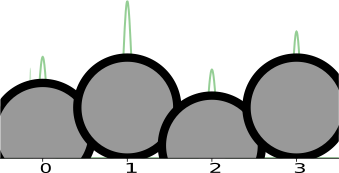

Черные точки представляют собой дискретные точки, а зеленая диния – плотность, моделируемую нормализующим потоком в непрерывном пространстве. Поток будет продолжать увеличивать правдоподобие для $x=0,1,2,3$, не имея объема для всех остальных точек. Помните, что в непрерывном пространстве у нас есть ограничение: общий объем плотности вероятности должен быть равен 1 ($\int p(x)dx=1$). В противном случае мы больше не моделируем распределение вероятностей. Однако дискретные точки $x=0,1,2,3$ представляют собой дельта-пики без ширины в непрерывном пространстве. Именно поэтому поток может придавать этим нескольким точкам бесконечно высокое правдоподобие, продолжая при этом представлять распределение в непрерывном пространстве. Тем не менее, полученная плотность ничего не говорит нам о распределении между дискретными точками, поскольку в дискретном пространстве сумма правдоподобий этих четырех точек должна быть равна 1, а не бесконечности.

Чтобы предотвратить подобные вырожденные решения, распространенным решением является добавление небольшого количества шума к каждому дискретному значению, что также называется __деквантованием__. Рассматривая $x$ как целое число (как это имеет место для изображений), деквантованное представление $v$ можно сформулировать как $v=x+u$, где $u\in[0,1)^D$. Таким образом, дискретное значение $1$ моделируется распределением в интервале $[1.0, 2.0)$, значение $2$ — распределением в интервале $[2.0, 3.0)$ и т. д. Наша цель моделирования $p(x)$ принимает вид:

$$ p(x) = \int p(x+u)du = \int \frac{q(u|x)}{q(u|x)}p(x+u)du = \mathbb{E}_{u\sim q(u|x)}\left[\frac{p(x+u)}{q(u|x)} \right],$$

где $q(u|x)$ — распределение шума. На данный момент мы предполагаем, что он равномерен, что также можно записать как $p(x)=\mathbb{E}_{u\sim U(0,1)^D}\left[p(x+u) \right]$.

Далее мы реализуем деквантование как преобразование потока. После добавления шума к дискретным значениям мы дополнительно преобразуем объём в гауссово-подобную форму. Это достигается масштабированием $x+u$ от $0$ до $1$ и применением инвертированной сигмоидальной функции $\sigma(z)^{-1} = \log z - \log 1-z$. В противном случае мы столкнёмся с двумя проблемами:

1. Входные данные масштабируются от 0 до 256, в то время как априорное распределение является гауссовым со средним $0$ и стандартным отклонением $1$. На первых итерациях после инициализации параметров потока мы будем иметь крайне низкие правдоподобия для больших значений, таких как $256$. Это привело бы к мгновенному расхождению обучения.
2. Поскольку выходное распределение является гауссовым, потоку выгодно иметь аналогичное входное распределение. Это уменьшит сложность моделирования, необходимую для потока.

В целом, мы можем реализовать деквантование следующим образом:

In [5]:
class Dequantization(nn.Module):
    
    def __init__(self, alpha=1e-5, quants=256):
        """
        Inputs:
            alpha - small constant that is used to scale the original input. 
                    Prevents dealing with values very close to 0 and 1 when inverting the sigmoid
            quants - Number of possible discrete values (usually 256 for 8-bit image)
        """
        super().__init__()
        self.alpha = alpha
        self.quants = quants 
        
    def forward(self, z, ldj, reverse=False):
        if not reverse:
            z, ldj = self.dequant(z, ldj)
            z, ldj = self.sigmoid(z, ldj, reverse=True)
        else:
            z, ldj = self.sigmoid(z, ldj, reverse=False)
            z = z * self.quants
            ldj += np.log(self.quants) * np.prod(z.shape[1:])
            z = torch.floor(z).clamp(min=0, max=self.quants-1).to(torch.int32)
        return z, ldj
    
    def sigmoid(self, z, ldj, reverse=False):
        # Applies an invertible sigmoid transformation
        if not reverse:
            ldj += (-z-2*F.softplus(-z)).sum(dim=[1,2,3])
            z = torch.sigmoid(z)
            # Reversing scaling for numerical stability
            ldj -= np.log(1 - self.alpha) * np.prod(z.shape[1:])
            z = (z - 0.5 * self.alpha) / (1 - self.alpha)
        else:
            z = z * (1 - self.alpha) + 0.5 * self.alpha  # Scale to prevent boundaries 0 and 1
            ldj += np.log(1 - self.alpha) * np.prod(z.shape[1:])
            ldj += (-torch.log(z) - torch.log(1-z)).sum(dim=[1,2,3])
            z = torch.log(z) - torch.log(1-z)
        return z, ldj
    
    def dequant(self, z, ldj):
        # Transform discrete values to continuous volumes
        z = z.to(torch.float32)
        z = z + torch.rand_like(z).detach()
        z = z / self.quants
        ldj -= np.log(self.quants) * np.prod(z.shape[1:])
        return z, ldj

Хорошей проверкой корректности реализации потока является проверка его обратимости. Поэтому мы деквантуем случайно выбранное обучающее изображение, а затем квантуем его снова. Ожидается, что на выходе получим точно такое же изображение:

In [6]:
## Testing invertibility of dequantization layer
pl.seed_everything(42)
orig_img = train_set[0][0].unsqueeze(dim=0)
ldj = torch.zeros(1,)
dequant_module = Dequantization()
deq_img, ldj = dequant_module(orig_img, ldj, reverse=False)
reconst_img, ldj = dequant_module(deq_img, ldj, reverse=True)

d1, d2 = torch.where(orig_img.squeeze() != reconst_img.squeeze())
if len(d1) != 0:
    print("Dequantization was not invertible.")
    for i in range(d1.shape[0]):
        print("Original value:", orig_img[0,0,d1[i], d2[i]].item())
        print("Reconstructed value:", reconst_img[0,0,d1[i], d2[i]].item())
else:
    print("Successfully inverted dequantization")

# Layer is not strictly invertible due to float precision constraints
# assert (orig_img == reconst_img).all().item()

Seed set to 42


Successfully inverted dequantization


Тест проходит успешно, как и ожидалось. Однако существует вероятность, что тест не пройдёт из-за числовых погрешностей при инвертировании сигмоиды. Входное пространство инвертированной сигмоиды масштабируется от 0 до 1, а выходное — от $-\infty$ до $\infty$. Поскольку для представления чисел мы используем 32 бита (в дополнение к многократному применению логарифмов), такие погрешности могут возникать и не должны вызывать беспокойства. Тем не менее, полезно знать о них, и их можно улучшить, используя двойную точность (float64).

Наконец, мы можем взять наше деквантование и визуализировать распределение, в которое оно преобразует дискретные значения:

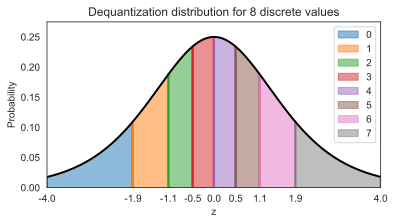

In [7]:
def visualize_dequantization(quants, prior=None):
    """
    Function for visualizing the dequantization values of discrete values in continuous space
    """
    # Prior over discrete values. If not given, a uniform is assumed
    if prior is None:
        prior = np.ones(quants, dtype=np.float32) / quants
    prior = prior / prior.sum()  # Ensure proper categorical distribution

    inp = torch.arange(-4, 4, 0.01).view(-1, 1, 1, 1) # Possible continuous values we want to consider
    ldj = torch.zeros(inp.shape[0])
    dequant_module = Dequantization(quants=quants)
    # Invert dequantization on continuous values to find corresponding discrete value
    out, ldj = dequant_module.forward(inp, ldj, reverse=True)
    inp, out, prob = inp.squeeze().numpy(), out.squeeze().numpy(), ldj.exp().numpy()
    prob = prob * prior[out] # Probability scaled by categorical prior
    
    # Plot volumes and continuous distribution
    sns.set_style("white")
    fig = plt.figure(figsize=(6,3))
    x_ticks = []
    for v in np.unique(out):
        indices = np.where(out==v)
        color = to_rgb(f"C{v}")
        plt.fill_between(inp[indices], prob[indices], np.zeros(indices[0].shape[0]), color=color+(0.5,), label=str(v))
        plt.plot([inp[indices[0][0]]]*2,  [0, prob[indices[0][0]]],  color=color)
        plt.plot([inp[indices[0][-1]]]*2, [0, prob[indices[0][-1]]], color=color)
        x_ticks.append(inp[indices[0][0]])
    x_ticks.append(inp.max())
    plt.xticks(x_ticks, [f"{x:.1f}" for x in x_ticks])
    plt.plot(inp,prob, color=(0.0,0.0,0.0))
    # Set final plot properties
    plt.ylim(0, prob.max()*1.1)
    plt.xlim(inp.min(), inp.max())
    plt.xlabel("z")
    plt.ylabel("Probability")
    plt.title(f"Dequantization distribution for {quants} discrete values")
    plt.legend()
    plt.show()
    plt.close()
    
visualize_dequantization(quants=8)

Визуализированное распределение показывает подобъёмы, назначенные различным дискретным значениям. Значение $0$ имеет объём в диапазоне $[-\infty, -1,9)$, значение $1$ представлено интервалом $[-1,9, -1,1)$ и т. д. Объём для каждого дискретного значения имеет одинаковую вероятность. Поэтому объёмы, близкие к центру (например, 3 и 4), имеют меньшую площадь на оси $z$, чем другие ($z$ используется для обозначения выходного сигнала всего потока деквантования).

Фактически, последовательный нормализующий поток моделирует дискретные изображения при помощи следующей целевой функции:

$$\log p(x) = \log \mathbb{E}_{u\sim q(u|x)}\left[\frac{p(x+u)}{q(u|x)} \right] \geq \mathbb{E}_{u}\left[\log \frac{p(x+u)}{q(u|x)} \right]$$

Хотя нормализующие потоки точны по правдоподобию, у нас есть нижняя граница. Более конкретно, это пример выполнения неравенства Йенсена, поскольку нам необходимо перенести логарифм в математическое ожидание, чтобы можно было использовать оценки Монте-Карло. В общем случае эта граница значительно меньше, чем показатель ELBO в вариационных автокодировщиках. Фактически, мы можем сами снизить границу, оценивая математическое ожидание не по одной, а по $M$ точкам. Другими словами, мы можем использовать выборку по важности (importance sampling), которая приводит к следующему неравенству:

$$\log p(x) = \log \mathbb{E}_{u\sim q(u|x)}\left[\frac{p(x+u)}{q(u|x)} \right] \geq \mathbb{E}_{u}\left[\log \frac{1}{M} \sum_{m=1}^{M} \frac{p(x+u_m)}{q(u_m|x)} \right] \geq \mathbb{E}_{u}\left[\log \frac{p(x+u)}{q(u|x)} \right]$$

Выборка по важности $\frac{1}{M} \sum_{m=1}^{M} \frac{p(x+u_m)}{q(u_m|x)}$ становится $\mathbb{E}_{u\sim q(u|x)}\left[\frac{p(x+u)}{q(u|x)} \right]$, если $M\to \infty$, поэтому чем больше точек мы используем, тем точнее граница. Во время тестирования мы можем использовать это свойство и реализовать его в методе `test_step` в `ImageFlow`. Теоретически мы также можем использовать эту более узкую границу во время обучения. Однако, как показали исследования, это не обязательно приводит к улучшению, учитывая дополнительные вычислительные затраты, и эффективнее использовать одну оценку.

### Вариационное деквантование

Деквантование использует равномерное распределение для шума $u$, что фактически приводит к представлению изображений в виде гиперкубов (кубов высокой размерности) с резкими границами. Однако моделирование таких резких границ для потока данных представляет собой сложную задачу, поскольку для преобразования его в гауссово распределение используются плавные преобразования.

Другой способ рассмотреть это — изменить априорное распределение в предыдущей визуализации. Представьте, что у нас есть независимый гауссов шум на пикселях, что обычно встречается на любых реальных снимках. Следовательно, поток должен моделировать распределение, как указано выше, но с отдельными объёмами, масштабированными следующим образом:

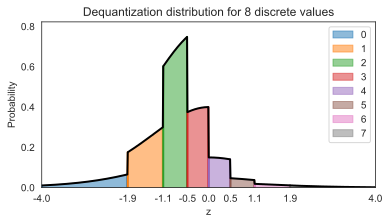

In [8]:
visualize_dequantization(quants=8, prior=np.array([0.075, 0.2, 0.4, 0.2, 0.075, 0.025, 0.0125, 0.0125]))

Преобразование такой вероятности в гауссово распределение — сложная задача, особенно при столь резких границах. Поэтому деквантование было распространено на более сложные, легко обучаемые распределения, выходящие за рамки равномерного в вариационном подходе. В частности, если вспомнить целевую функцию обучения $\log p(x) = \log \mathbb{E}_{u}\left[\frac{p(x+u)}{q(u|x)} \right]$, то равномерное распределение можно заменить обученным распределением $q_{\theta}(u|x)$ с носителем на множестве $u\in[0,1)^D$. Этот подход называется __вариационным деквантованием__. Как можно обучить такое распределение? Мы можем использовать второй нормализующий поток, который принимает $x$ в качестве внешнего входного значения и обучается гибкому распределению на $u$. Чтобы обеспечить поддержку на $[0,1)^D$, мы можем применить сигмоидальную функцию активации в качестве окончательного преобразования потока.

Унаследовав исходный класс деквантования, мы можем реализовать вариационную деквантование следующим образом:

In [9]:
class VariationalDequantization(Dequantization):
    
    def __init__(self, var_flows, alpha=1e-5):
        """
        Inputs: 
            var_flows - A list of flow transformations to use for modeling q(u|x)
            alpha - Small constant, see Dequantization for details
        """
        super().__init__(alpha=alpha)
        self.flows = nn.ModuleList(var_flows)
        
    def dequant(self, z, ldj):
        z = z.to(torch.float32)
        img = (z / 255.0) * 2 - 1 # We condition the flows on x, i.e. the original image
        
        # Prior of u is a uniform distribution as before
        # As most flow transformations are defined on [-infinity,+infinity], we apply an inverse sigmoid first.
        deq_noise = torch.rand_like(z).detach()
        deq_noise, ldj = self.sigmoid(deq_noise, ldj, reverse=True)
        for flow in self.flows:
            deq_noise, ldj = flow(deq_noise, ldj, reverse=False, orig_img=img)
        deq_noise, ldj = self.sigmoid(deq_noise, ldj, reverse=False)
        
        # After the flows, apply u as in standard dequantization
        z = (z + deq_noise) / 256.0
        ldj -= np.log(256.0) * np.prod(z.shape[1:])
        return z, ldj

Вариационное деквантование может быть использовано в качестве замены деквантованию. Мы сравним деквантование и вариационное деквантование в последующих экспериментах.

### Связующие слои

Далее мы рассмотрим возможные преобразования, применяемые внутри потока. Популярный в последнее время слой потока, хорошо работающий в сочетании с глубокими нейронными сетями, — это __связующий слой__ (coupling layer). Входные данные $z$ произвольно делятся на две части, $z_{1:j}$ и $z_{j+1:d}$, из которых первая остаётся неизменной потоком. При этом $z_{1:j}$ используется для параметризации преобразования второй части, $z_{j+1:d}$. В последнее время были предложены различные варианты преобразований, но здесь мы остановимся на самом простом и эффективном: __аффинном связывании__. В этом связующем слое мы применяем аффинное преобразование, сдвигая входные данные на смещение $\mu$ и масштабируя их на $\sigma$. Другими словами, наше преобразование выглядит следующим образом:

$$z'_{j+1:d} = \mu_{\theta}(z_{1:j}) + \sigma_{\theta}(z_{1:j}) \odot z_{j+1:d}$$

Функции $\mu$ и $\sigma$ реализованы как разделяемая (shared) нейронная сеть, а суммирование и умножение выполняются поэлементно. Таким образом, LDJ (log determinant jacobian) представляет собой сумму логарифмов масштабирующих коэффициентов: $\sum_i \left[\log \sigma_{\theta}(z_{1:j})\right]_i$. Инвертировать слой можно так же просто, как вычесть смещение и разделить на масштаб:

$$z_{j+1:d} = \left(z'_{j+1:d} - \mu_{\theta}(z_{1:j})\right) / \sigma_{\theta}(z_{1:j})$$

Мы также можем визуализировать слой связи в виде вычислительного графа, где $z_1$ представляет $z_{1:j}$, а $z_2$ представляет $z_{j+1:d}$:

<!--center width="100%" style="padding: 10px"><img src="coupling_flow.svg" width="450px"></center-->

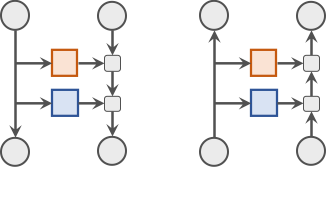

В нашей реализации мы реализуем разделение переменных как __маскирование__. Преобразуемые переменные $z_{j+1:d}$ маскируются при передаче $z$ в разделяемую сеть для прогнозирования параметров преобразования. При применении преобразования мы маскируем параметры для $z_{1:j}$, чтобы обеспечить тождественную операцию для этих переменных:

In [10]:
class CouplingLayer(nn.Module):
    
    def __init__(self, network, mask, c_in):
        """
        Coupling layer inside a normalizing flow.
        Inputs:
            network - A PyTorch nn.Module constituting the deep neural network for mu and sigma.
                      Output shape should be twice the channel size as the input.
            mask - Binary mask (0 or 1) where 0 denotes that the element should be transformed,
                   while 1 means the latent will be used as input to the NN.
            c_in - Number of input channels
        """
        super().__init__()
        self.network = network
        self.scaling_factor = nn.Parameter(torch.zeros(c_in))
        # Register mask as buffer as it is a tensor which is not a parameter, 
        # but should be part of the modules state.
        self.register_buffer('mask', mask)
    
    def forward(self, z, ldj, reverse=False, orig_img=None):
        """
        Inputs:
            z - Latent input to the flow
            ldj - The current ldj of the previous flows. 
                  The ldj of this layer will be added to this tensor.
            reverse - If True, we apply the inverse of the layer.
            orig_img (optional) - Only needed in VarDeq. Allows external
                                  input to condition the flow on (e.g. original image)
        """
        # Apply network to masked input
        z_in = z * self.mask
        if orig_img is None:
            nn_out = self.network(z_in)
        else:
            nn_out = self.network(torch.cat([z_in, orig_img], dim=1))
        s, t = nn_out.chunk(2, dim=1)
        
        # Stabilize scaling output
        s_fac = self.scaling_factor.exp().view(1, -1, 1, 1)
        s = torch.tanh(s / s_fac) * s_fac
        
        # Mask outputs (only transform the second part)
        s = s * (1 - self.mask)
        t = t * (1 - self.mask)
        
        # Affine transformation
        if not reverse:
            # Whether we first shift and then scale, or the other way round,
            # is a design choice, and usually does not have a big impact
            z = (z + t) * torch.exp(s)
            ldj += s.sum(dim=[1,2,3])
        else:
            z = (z * torch.exp(-s)) - t
            ldj -= s.sum(dim=[1,2,3])
            
        return z, ldj

Для стабилизации мы применяем функцию активации $\tanh$ к масштабированным выходным данным. Это предотвращает резкие резкие скачки выходных значений, которые могут дестабилизировать обучение. Чтобы по-прежнему допускать масштабирующие коэффициенты, меньшие или большие, чем -1 и 1 соответственно, мы используем обучаемый параметр для каждого измерения, называемый `scaling_factor`. Он масштабирует $\tanh$ до различных пределов. Ниже мы визуализируем влияние масштабирующего коэффициента на активацию выходных данных масштабирующих членов:

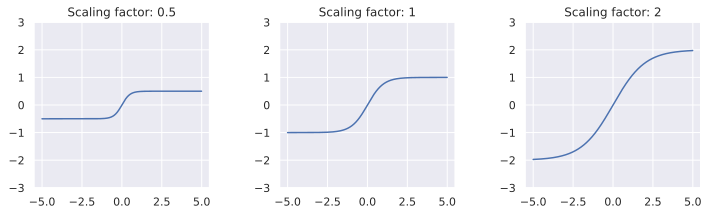

In [11]:
with torch.no_grad():
    x = torch.arange(-5,5,0.01)
    scaling_factors = [0.5, 1, 2]
    sns.set()
    fig, ax = plt.subplots(1, 3, figsize=(12,3))
    for i, scale in enumerate(scaling_factors):
        y = torch.tanh(x / scale) * scale
        ax[i].plot(x.numpy(), y.numpy())
        ax[i].set_title("Scaling factor: " + str(scale))
        ax[i].set_ylim(-3, 3)
    plt.subplots_adjust(wspace=0.4)
    sns.reset_orig()
    plt.show()

Связующие слои обобщаются для любого метода маскирования. Однако наиболее распространённый подход для изображений — это разделение входного $z$ пополам с помощью шахматной маски или маски канала. Шахматная маска разделяет переменные по высоте и ширине и присваивает каждому пикселю значение $z_{j+1:d}$. Таким образом, маска является общей для всех каналов. В отличие от этого, маска канала присваивает половину каналов значению $z_{j+1:d}$, а другую половину — значению $z_{1:j+1}$. Обратите внимание, что при применении нескольких связующих слоёв мы инвертируем маскирование для каждого слоя, так что каждая переменная преобразуется одинаковое количество раз.

Давайте реализуем функцию, которая создаёт шахматную маску и маску канала:

In [12]:
def create_checkerboard_mask(h, w, invert=False):
    x, y = torch.arange(h, dtype=torch.int32), torch.arange(w, dtype=torch.int32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    mask = torch.fmod(xx + yy, 2)
    mask = mask.to(torch.float32).view(1, 1, h, w)
    if invert:
        mask = 1 - mask
    return mask

def create_channel_mask(c_in, invert=False):
    mask = torch.cat([torch.ones(c_in//2, dtype=torch.float32), 
                      torch.zeros(c_in-c_in//2, dtype=torch.float32)])
    mask = mask.view(1, c_in, 1, 1)
    if invert:
        mask = 1 - mask
    return mask

Мы также можем визуализировать соответствующие маски для изображения размером $8\times 8\times 2$ (2 канала):

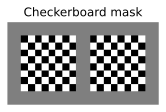

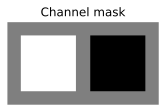

In [13]:
checkerboard_mask = create_checkerboard_mask(h=8, w=8).expand(-1,2,-1,-1)
channel_mask = create_channel_mask(c_in=2).expand(-1,-1,8,8)

show_imgs(checkerboard_mask.transpose(0,1), "Checkerboard mask")
show_imgs(channel_mask.transpose(0,1), "Channel mask")

В качестве последнего аспекта связующих слоёв нам необходимо выбрать глубокую нейронную сеть, которую мы хотим использовать в связующих слоях. Входными данными для слоёв является изображение, поэтому мы используем сверточную нейронную сеть (CNN). Поскольку входные данные для преобразования зависят от всех предыдущих преобразований, крайне важно обеспечить хороший градиентный поток через CNN обратно к входным данным, что оптимально достигается с помощью архитектуры, подобной ResNet. В частности, мы используем Gated ResNet, которая добавляет $\sigma$-вентиль к пропускному соединению (skip connection), аналогично входному вентилю в LSTM-сетях. 

In [14]:
class ConcatELU(nn.Module):
    """
    Activation function that applies ELU in both direction (inverted and plain). 
    Allows non-linearity while providing strong gradients for any input (important for final convolution)
    """
    
    def forward(self, x):
        return torch.cat([F.elu(x), F.elu(-x)], dim=1)

    
class LayerNormChannels(nn.Module):
    
    def __init__(self, c_in, eps=1e-5):
        """
        This module applies layer norm across channels in an image.
        Inputs: 
            c_in - Number of channels of the input
            eps - Small constant to stabilize std
        """
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(1, c_in, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, c_in, 1, 1))
        self.eps = eps
    
    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, unbiased=False, keepdim=True)
        y = (x - mean) / torch.sqrt(var + self.eps)
        y = y * self.gamma + self.beta
        return y

    
class GatedConv(nn.Module):
    
    def __init__(self, c_in, c_hidden):
        """
        This module applies a two-layer convolutional ResNet block with input gate
        Inputs:
            c_in - Number of channels of the input
            c_hidden - Number of hidden dimensions we want to model (usually similar to c_in)
        """
        super().__init__()
        self.net = nn.Sequential(
            ConcatELU(),
            nn.Conv2d(2*c_in, c_hidden, kernel_size=3, padding=1),
            ConcatELU(),
            nn.Conv2d(2*c_hidden, 2*c_in, kernel_size=1)
        )
    
    def forward(self, x):
        out = self.net(x)
        val, gate = out.chunk(2, dim=1)
        return x + val * torch.sigmoid(gate)

    
class GatedConvNet(nn.Module):
    
    def __init__(self, c_in, c_hidden=32, c_out=-1, num_layers=3):
        """
        Module that summarizes the previous blocks to a full convolutional neural network.
        Inputs:
            c_in - Number of input channels
            c_hidden - Number of hidden dimensions to use within the network
            c_out - Number of output channels. If -1, 2 times the input channels are used (affine coupling)
            num_layers - Number of gated ResNet blocks to apply
        """
        super().__init__()
        c_out = c_out if c_out > 0 else 2 * c_in
        layers = []
        layers += [nn.Conv2d(c_in, c_hidden, kernel_size=3, padding=1)]
        for layer_index in range(num_layers):
            layers += [GatedConv(c_hidden, c_hidden),
                       LayerNormChannels(c_hidden)]
        layers += [ConcatELU(),
                   nn.Conv2d(2*c_hidden, c_out, kernel_size=3, padding=1)]
        self.nn = nn.Sequential(*layers)
        
        self.nn[-1].weight.data.zero_()
        self.nn[-1].bias.data.zero_()
    
    def forward(self, x):
        return self.nn(x)

### Цикл обучения

Наконец, мы можем объединить слои деквантования, вариационного деквантования и связывания, чтобы построить наш полноценный нормализующий поток на изображениях MNIST. Мы используем 8 связующих слоёв в основном потоке и 4 для вариационного деквантования, если оно применяется. Мы применяем шахматную маску ко всей сети, как и в случае с одним каналом (чёрно-белые изображения), поэтому мы не можем применять маску канала. Общая архитектура представлена ниже.

<!--center width="100%" style="padding: 20px"><img src="vanilla_flow.svg" width="900px"></center-->

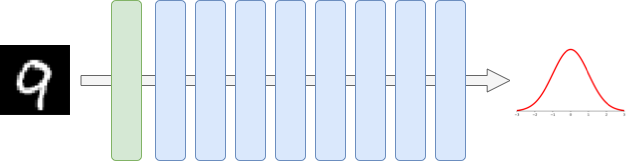

In [15]:
def create_simple_flow(use_vardeq=True):
    flow_layers = []
    if use_vardeq:
        vardeq_layers = [CouplingLayer(network=GatedConvNet(c_in=2, c_out=2, c_hidden=16),
                                       mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                       c_in=1) for i in range(4)]
        flow_layers += [VariationalDequantization(var_flows=vardeq_layers)]
    else:
        flow_layers += [Dequantization()]
    
    for i in range(8):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=1, c_hidden=32),
                                      mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                      c_in=1)]
        
    flow_model = ImageFlow(flow_layers).to(device)
    return flow_model

Для реализации цикла обучения мы используем фреймворк PyTorch Lightning, что позволяет сократить объём кода. Если рассмотреть сгенерированный файл Tensorboard, то можно  увидеть обзор применяемых преобразований потока. Мы используем предварительно обученные модели, поскольку нормализация потоков требует больших затрат вычислительных ресурсов на обучение. Мы также провели валидацию и тестирование, поскольку это также может занять некоторое время из-за дополнительной выборки.

In [16]:
def train_flow(flow, model_name="MNISTFlow"):
    # Create a PyTorch Lightning trainer
    trainer = pl.Trainer(default_root_dir=os.path.join(CHECKPOINT_PATH, model_name), 
                         accelerator="gpu" if str(device).startswith("cuda") else "cpu",
                         devices=1,
                         max_epochs=200, 
                         gradient_clip_val=1.0,
                         callbacks=[ModelCheckpoint(save_weights_only=True, mode="min", monitor="val_bpd"),
                                    LearningRateMonitor("epoch")],
                         check_val_every_n_epoch=5)
    trainer.logger._log_graph = True
    trainer.logger._default_hp_metric = None # Optional logging argument that we don't need
    
    train_data_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=8)
    result = None
    
    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(CHECKPOINT_PATH, model_name + ".ckpt")
    if os.path.isfile(pretrained_filename):
        print("Found pretrained model, loading...")
        ckpt = torch.load(pretrained_filename, map_location=device)
        flow.load_state_dict(ckpt['state_dict'])
        result = ckpt.get("result", None)
    else:
        print("Start training", model_name)
        trainer.fit(flow, train_data_loader, val_loader)
    
    # Test best model on validation and test set if no result has been found
    # Testing can be expensive due to the importance sampling.
    if result is None:
        val_result = trainer.test(flow, val_loader, verbose=False)
        start_time = time.time()
        test_result = trainer.test(flow, test_loader, verbose=False)
        duration = time.time() - start_time
        result = {"test": test_result, "val": val_result, "time": duration / len(test_loader) / flow.import_samples}
    
    return flow, result

## Многомасштабная архитектура

Одним из недостатков нормализации потоков является то, что они работают с теми же измерениями, что и входные данные. Если входные данные многомерны, то и скрытое пространство также многомерно, что требует больших вычислительных затрат для обучения подходящим преобразованиям. Однако, особенно в области изображений, многие пиксели содержат меньше информации в том смысле, что мы можем удалить их без потери семантической информации изображения.

Исходя из этих соображений для глубокой нормализации потоков изображений обычно применяется многомасштабная архитектура (multi-scale architecture). После первых $N$ преобразований потока мы отделяем половину скрытых измерений и непосредственно оцениваем их на основе априорных данных. Другая половина проходит ещё $N$ преобразований потока, и в зависимости от размера входных данных мы снова делим их пополам или останавливаемся на этом месте. В этой схеме задействованы две операции:  `Squeeze` (сжатие) и `Split` (разделение), которые мы более подробно рассмотрим и реализуем ниже.

### Сжатие и разделение

Когда мы хотим удалить половину пикселей из изображения, возникает проблема выбора переменных, которые нужно вырезать, и способа перегруппировки изображения. Поэтому операция сжатия обычно используется перед разделением, которая делит изображение на подквадраты размером $2x2xC$ и преобразует их в блоки размером $1x1x4C$. Фактически, мы уменьшаем высоту и ширину изображения в 2 раза, одновременно масштабируя количество каналов в 4 раза. После этого мы можем выполнить операцию разделения по каналам без необходимости перегруппировки пикселей. Меньший масштаб также делает общую архитектуру более эффективной. Визуально операция сжатия должна преобразовать входные данные следующим образом:

<!--center><img src="Squeeze_operation.svg" width="40%"/></center-->

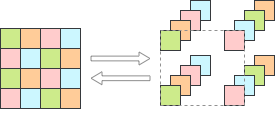

Входные данные $4\times 4\times 1$ масштабируются до $2\times 2\times 4$, следуя идее группировки пикселей в подквадраты размером $2\times 2\times 1$. Далее попробуем реализовать этот слой:

In [17]:
class SqueezeFlow(nn.Module):
    
    def forward(self, z, ldj, reverse=False):
        B, C, H, W = z.shape
        if not reverse: 
            # Forward direction: H x W x C => H/2 x W/2 x 4C
            z = z.reshape(B, C, H//2, 2, W//2, 2)
            z = z.permute(0, 1, 3, 5, 2, 4)
            z = z.reshape(B, 4*C, H//2, W//2)
        else: 
            # Reverse direction: H/2 x W/2 x 4C => H x W x C
            z = z.reshape(B, C//4, 2, 2, H, W)
            z = z.permute(0, 1, 4, 2, 5, 3)
            z = z.reshape(B, C//4, H*2, W*2)
        return z, ldj

Прежде чем двигаться дальше, мы можем проверить нашу реализацию, сравнив наш вывод с примером на рисунке выше:

In [18]:
sq_flow = SqueezeFlow()
rand_img = torch.arange(1,17).view(1, 1, 4, 4)
print("Image (before)\n", rand_img)
forward_img, _ = sq_flow(rand_img, ldj=None, reverse=False)
print("\nImage (forward)\n", forward_img.permute(0,2,3,1)) # Permute for readability
reconst_img, _ = sq_flow(forward_img, ldj=None, reverse=True)
print("\nImage (reverse)\n", reconst_img)

Image (before)
 tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]]]])

Image (forward)
 tensor([[[[ 1,  2,  5,  6],
          [ 3,  4,  7,  8]],

         [[ 9, 10, 13, 14],
          [11, 12, 15, 16]]]])

Image (reverse)
 tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]]]])


Операция `split` делит входные данные на две части и оценивает одну из них непосредственно на основе априорной вероятности. Чтобы наша операция потока соответствовала реализации предыдущих слоёв, мы вернём априорную вероятность первой части как логарифм детерминанта якобиана слоя. Это даёт тот же эффект, что и объединение всех разделений переменных в конце потока и их совместная оценка на основе априорной вероятности.

In [19]:
class SplitFlow(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.prior = torch.distributions.normal.Normal(loc=0.0, scale=1.0)
    
    def forward(self, z, ldj, reverse=False):
        if not reverse:
            z, z_split = z.chunk(2, dim=1)
            ldj += self.prior.log_prob(z_split).sum(dim=[1,2,3])
        else:
            z_split = self.prior.sample(sample_shape=z.shape).to(device)
            z = torch.cat([z, z_split], dim=1)
            ldj -= self.prior.log_prob(z_split).sum(dim=[1,2,3])
        return z, ldj

### Построение многомасштабного потока

После определения операций сжатия и разделения мы наконец-то можем построить свой собственный многомасштабный поток. Глубокие нормализующие потоки часто применяют операцию разделения сразу после сжатия. Однако в случае с неглубокими потоками нам нужно более продуманно подходить к размещению операции разделения, поскольку нам требуется как минимум минимальное количество преобразований для каждой переменной. Наша конфигурация основана на оригинальной архитектуре RealNVP, которая менее глубока, чем другие, более современные архитектуры.

Следовательно, для набора данных MNIST мы применим первую операцию сжатия после двух связующих слоёв, но пока не будем применять операцию разделения. Поскольку мы использовали только связующих два слоя, и каждый из них был преобразован только один раз, операция разделения была бы преждевременной. Мы применяем ещё два связующих слоя, прежде чем, наконец, применить разделение потока и повторное сжатие. Последние четыре связующих слоя работают в масштабе $7x7x8$. Полная архитектура потока показана ниже.

<!--center width="100%" style="padding: 20px"><img src="multiscale_flow.svg" width="1100px"></center-->

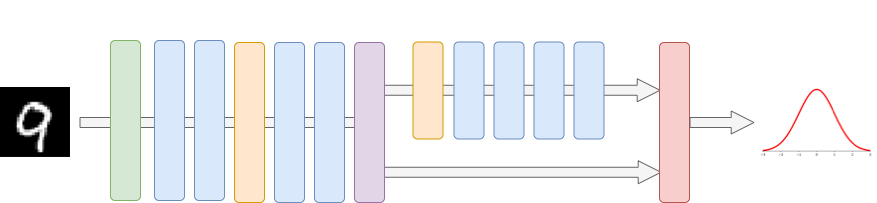

Обратите внимание, что, хотя карты признаков внутри связующих слоёв уменьшаются с высотой и шириной входных данных, увеличение количества каналов напрямую не учитывается. Чтобы компенсировать это, мы увеличиваем скрытые размерности для связующих слоёв на сжатых входных данных. Размерности часто масштабируются в 2 раза, поскольку это примерно в 4 раза увеличивает вычислительные затраты, компенсируя операцию сжатия. Тем не менее, мы выберем скрытые размерности $32, 48 и 64$ для трёх масштабов соответственно, чтобы сохранить разумное количество параметров и продемонстрировать эффективность многомасштабных архитектур.

In [20]:
def create_multiscale_flow():
    flow_layers = []
    
    vardeq_layers = [CouplingLayer(network=GatedConvNet(c_in=2, c_out=2, c_hidden=16),
                                   mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                   c_in=1) for i in range(4)]
    flow_layers += [VariationalDequantization(vardeq_layers)]
    
    flow_layers += [CouplingLayer(network=GatedConvNet(c_in=1, c_hidden=32),
                                  mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                  c_in=1) for i in range(2)]
    flow_layers += [SqueezeFlow()]
    for i in range(2):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=4, c_hidden=48),
                                      mask=create_channel_mask(c_in=4, invert=(i%2==1)),
                                      c_in=4)]
    flow_layers += [SplitFlow(),
                    SqueezeFlow()]
    for i in range(4):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=8, c_hidden=64),
                                      mask=create_channel_mask(c_in=8, invert=(i%2==1)),
                                      c_in=8)]

    flow_model = ImageFlow(flow_layers).to(device)
    return flow_model

Ниже мы можем показать разницу в количестве параметров:

In [21]:
def print_num_params(model):
    num_params = sum([np.prod(p.shape) for p in model.parameters()])
    print("Number of parameters: {:,}".format(num_params))

print_num_params(create_simple_flow(use_vardeq=False))
print_num_params(create_simple_flow(use_vardeq=True))
print_num_params(create_multiscale_flow())

Number of parameters: 556,312
Number of parameters: 628,388
Number of parameters: 1,711,818


Хотя многомасштабный поток имеет почти в три раза больше параметров, чем одномасштабный, он не обязательно требует больших вычислительных затрат, чем его аналог. Мы также сравним время выполнения в следующих экспериментах.

## Анализ потоков

Обучим все реализованные выше модели и попытаемся проанализировать влияние многомасштабной архитектуры и вариационного деквантования.

### Варианты обучающего потока

Прежде чем анализировать модели потоков, необходимо их обучить. Мы используем предобученные модели, содержащие данные о валидации и тестировании, а также информацию о времени выполнения. Поскольку модели нормализующих потоков требуют больших вычислительных затрат, рекомендуется использовать предобученные модели.

In [22]:
flow_dict = {"simple": {}, "vardeq": {}, "multiscale": {}}
flow_dict["simple"]["model"], flow_dict["simple"]["result"] = train_flow(create_simple_flow(use_vardeq=False), model_name="MNISTFlow_simple")
flow_dict["vardeq"]["model"], flow_dict["vardeq"]["result"] = train_flow(create_simple_flow(use_vardeq=True), model_name="MNISTFlow_vardeq")
flow_dict["multiscale"]["model"], flow_dict["multiscale"]["result"] = train_flow(create_multiscale_flow(), model_name="MNISTFlow_multiscale")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Found pretrained model, loading...


/opt/anaconda3/envs/k3ptm/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/k3ptm/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Found pretrained model, loading...


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Found pretrained model, loading...


In [23]:
flow_dict["simple"]["result"]

{'test': [{'test_bpd': 1.07839834690094}],
 'val': [{'test_bpd': 1.0798484086990356}],
 'time': 0.019570968523147,
 'samp_time': 0.017716965675354003}

### Моделирование плотности и выборка

Можно сравнить модели по их количественным результатам. В следующей таблице представлены все важные статистические данные. Время вывода (inference time) определяет время, необходимое для определения вероятности для пакета из 64 изображений для каждой модели, а время выборки (sampling time) — это продолжительность выборки пакета из 64 изображений.

In [24]:
%%html
<!-- Some HTML code to increase font size in the following table -->
<style>
th {font-size: 120%;}
td {font-size: 120%;}
</style>

In [25]:
import tabulate
from IPython.display import display, HTML

table = [[key, 
          "%4.3f bpd" % flow_dict[key]["result"]["val"][0]["test_bpd"], 
          "%4.3f bpd" % flow_dict[key]["result"]["test"][0]["test_bpd"], 
          "%2.0f ms" % (1000 * flow_dict[key]["result"]["time"]),
          "%2.0f ms" % (1000 * flow_dict[key]["result"].get("samp_time", 0)),
          "{:,}".format(sum([np.prod(p.shape) for p in flow_dict[key]["model"].parameters()]))] 
         for key in flow_dict]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Model", "Validation Bpd", "Test Bpd", "Inference time", "Sampling time", "Num Parameters"])))

Model,Validation Bpd,Test Bpd,Inference time,Sampling time,Num Parameters
simple,1.080 bpd,1.078 bpd,20 ms,18 ms,"556,312"
vardeq,1.045 bpd,1.043 bpd,26 ms,18 ms,"628,388"
multiscale,1.022 bpd,1.020 bpd,23 ms,15 ms,"1,711,818"


Как мы изначально и ожидали, использование вариационного деквантования улучшает стандартное деквантование с точки зрения количества бит на измерение. Хотя разница в 0,04 bpd (bits per dimension) на первый взгляд не кажется впечатляющей, для генеративных моделей это значительный шаг (большинство современных моделей превосходят предыдущие модели в диапазоне 0,02–0,1 bpd на CIFAR с втрое большим количеством bpd). Хотя вариационное деквантование занимает больше времени для оценки вероятности изображения, что также приводит к увеличению времени обучения, это не влияет на время выборки. Это связано с тем, что инвертирование вариационного деквантования аналогично деквантованию: поиску следующего меньшего целого числа.

Сравнив две модели с моделью с многомасштабной архитектурой, мы видим, что количество бит на измерение снова снизилось примерно на 0,02 bpd. Кроме того, время выборки заметно улучшилось, несмотря на большее количество параметров. Таким образом, мы видим, что многомасштабный поток не только лучше подходит для моделирования плотности, но и эффективнее.

Далее мы можем проверить качество выборки моделей. Следует отметить, что выборки для вариационного деквантования и стандартного деквантования очень похожи, поэтому здесь мы визуализируем только выборки для вариационного деквантования и многомасштабной модели. Однако можно также протестировать «простую» модель. Начальные значения настроены на получение воспроизводимых поколений и не выбираются выборочно.

Seed set to 44


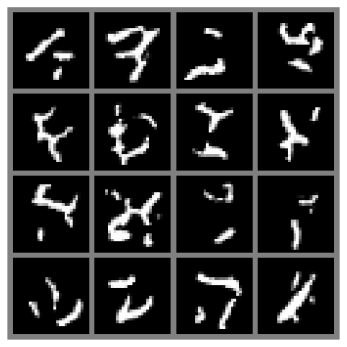

In [26]:
pl.seed_everything(44)
samples = flow_dict["vardeq"]["model"].sample(img_shape=[16,1,28,28])
show_imgs(samples.cpu())

Seed set to 42


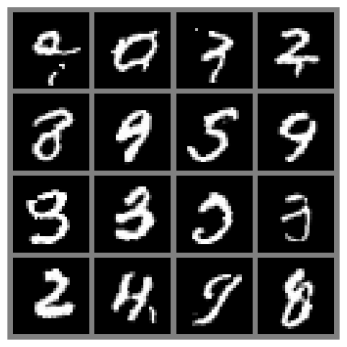

In [27]:
pl.seed_everything(42)
samples = flow_dict["multiscale"]["model"].sample(img_shape=[16,8,7,7])
show_imgs(samples.cpu())

На примере нескольких выборок мы видим чёткую разницу между простой и многомасштабной моделью. Одномасштабная модель изучила только локальные, небольшие корреляции, в то время как многомасштабная модель смогла извлечь полные, глобальные связи, формирующие цифры. Это демонстрирует ещё одно преимущество многомасштабной модели. В отличие от VAE, выходные данные точны, поскольку нормализующие потоки могут естественным образом моделировать сложные многомодальные распределения, в то время как VAE имеют независимый выходной шум декодера. Тем не менее, изображения этого потока далеки от идеала, поскольку не все изображения показывают истинные цифры.

### Интерполяция в латентном пространстве

Другой популярный тест на гладкость латентного пространства генеративных моделей — интерполяция между двумя обучающими изображениями. Поскольку нормализующие потоки строго обратимы, мы можем гарантировать, что любое изображение будет представлено в латентном пространстве. Ниже мы снова сравним модель вариационного деквантования с многомасштабной моделью.

In [28]:
@torch.no_grad()
def interpolate(model, img1, img2, num_steps=8):
    """
    Inputs:
        model - object of ImageFlow class that represents the (trained) flow model
        img1, img2 - Image tensors of shape [1, 28, 28]. Images between which should be interpolated.
        num_steps - Number of interpolation steps. 8 interpolation steps mean 6 intermediate pictures besides img1 and img2
    """
    imgs = torch.stack([img1, img2], dim=0).to(model.device)
    z, _ = model.encode(imgs)
    alpha = torch.linspace(0, 1, steps=num_steps, device=z.device).view(-1, 1, 1, 1)
    interpolations = z[0:1] * alpha + z[1:2] * (1 - alpha)
    interp_imgs = model.sample(interpolations.shape[:1] + imgs.shape[1:], z_init=interpolations)
    show_imgs(interp_imgs, row_size=8)

exmp_imgs, _ = next(iter(train_loader))

Seed set to 42


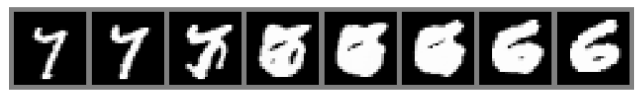

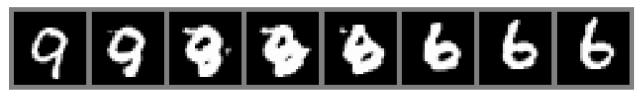

In [29]:
pl.seed_everything(42)
for i in range(2):
    interpolate(flow_dict["vardeq"]["model"], exmp_imgs[2*i], exmp_imgs[2*i+1])

Seed set to 42


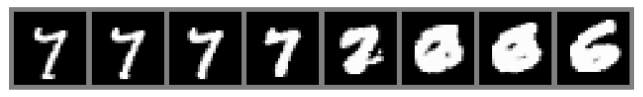

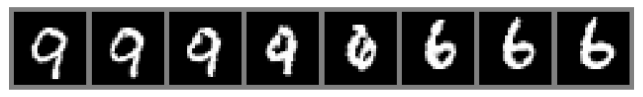

In [30]:
pl.seed_everything(42)
for i in range(2):
    interpolate(flow_dict["multiscale"]["model"], exmp_imgs[2*i], exmp_imgs[2*i+1])

Интерполяции многомасштабной модели приводят к более реалистичным цифрам (первая строка $7\leftrightarrow 8\leftrightarrow 6$, вторая строка $9\leftrightarrow 6$), в то время как  модель вариационного деквантования фокусируется на локальных паттернах, которые в глобальном масштабе не образуют цифру. Для многомасштабной модели мы фактически не проводили «истинную» интерполяцию между двумя изображениями, поскольку не учитывали переменные, разделённые вдоль потока (они были выбраны случайным образом для всех выборок). Однако, как мы увидим в следующем эксперименте, ранние переменные не оказывают существенного влияния на общее изображение.

### Визуализация латентных переменных на разных уровнях многомасштабности

Далее мы подробнее рассмотрим многомасштабный поток. Мы хотим проанализировать, какая информация хранится в переменных, разделённых на ранних уровнях, и какая информация — в конечных переменных. Для этого мы выбираем 8 изображений, каждое из которых имеет одинаковые конечные латентные переменные, но различается в остальной части латентных переменных. Ниже мы визуализируем три примера:

Seed set to 44


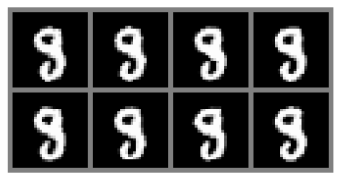

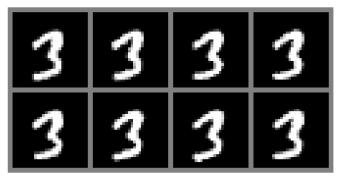

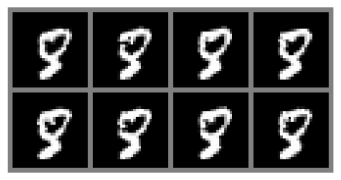

In [31]:
pl.seed_everything(44)
for _ in range(3):
    z_init = flow_dict["multiscale"]["model"].prior.sample(sample_shape=[1,8,7,7])
    z_init = z_init.expand(8, -1, -1, -1)
    samples = flow_dict["multiscale"]["model"].sample(img_shape=z_init.shape, z_init=z_init)
    show_imgs(samples.cpu())

Мы видим, что ранние разделённые переменные действительно оказывают меньшее влияние на изображение. Тем не менее, небольшие различия можно заметить, внимательно присмотревшись к границам цифр. Например, в середине верхняя часть цифры 3 имеет разную толщину для разных образцов, хотя все они представляют собой одну и ту же грубую структуру. Это показывает, что поток действительно обучается выделять информацию более высокого уровня в конечных переменных, в то время как ранние разделённые переменные содержат локальные шумовые паттерны.

### Визуализация деквантования

В заключение рассмотрим эффект вариационного деквантования. Мы обосновывали вариационное деквантование проблемой сложности моделирования резких границ, а поток предпочитает гладкие, похожие на априорные распределения. Чтобы проверить, как потоки в модуле вариационного деквантования усвоили распределение шума $q(u|x)$, мы можем построить гистограмму выходных значений модуля деквантования и вариационного деквантования.

In [32]:
def visualize_dequant_distribution(model : ImageFlow, imgs : torch.Tensor, title:str=None):
    """
    Inputs:
        model - The flow of which we want to visualize the dequantization distribution
        imgs - Example training images of which we want to visualize the dequantization distribution 
    """
    imgs = imgs.to(device)
    ldj = torch.zeros(imgs.shape[0], dtype=torch.float32).to(device)
    with torch.no_grad():
        dequant_vals = []
        for _ in tqdm(range(8), leave=False):
            d, _ = model.flows[0](imgs, ldj, reverse=False)
            dequant_vals.append(d)
        dequant_vals = torch.cat(dequant_vals, dim=0)
    dequant_vals = dequant_vals.view(-1).cpu().numpy()
    sns.set()
    plt.figure(figsize=(10,3))
    plt.hist(dequant_vals, bins=256, color=to_rgb("C0")+(0.5,), edgecolor="C0", density=True)
    if title is not None:
        plt.title(title)
    plt.show()
    plt.close()
    
sample_imgs, _ = next(iter(train_loader))

  0%|          | 0/8 [00:00<?, ?it/s]

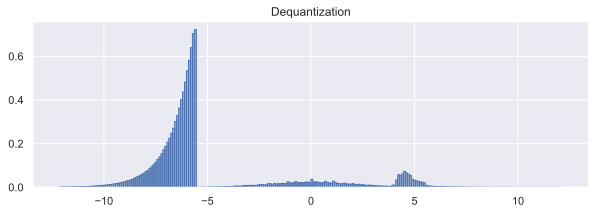

In [33]:
visualize_dequant_distribution(flow_dict["simple"]["model"], sample_imgs, title="Dequantization")

  0%|          | 0/8 [00:00<?, ?it/s]

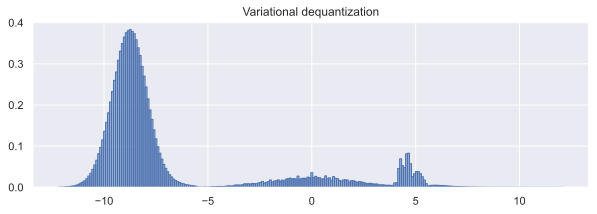

In [34]:
visualize_dequant_distribution(flow_dict["vardeq"]["model"], sample_imgs, title="Variational dequantization")

Распределение деквантования на первом графике показывает, что изображения MNIST имеют сильный сдвиг в сторону 0 (чёрный), а их распределение, как уже упоминалось, имеет резкую границу. Модуль вариационного деквантования действительно выучил гораздо более плавное распределение с гауссовой кривой, которую можно моделировать гораздо лучше. Для других значений нам потребуется визуализировать распределение $q(u|x)$ на более глубоком уровне, в зависимости от $x$. Однако, поскольку все $u$ взаимодействуют и зависят друг от друга, нам потребуется визуализировать распределение в 784 измерениях, что уже не так интуитивно понятно.

## Заключение

Мы рассмотрели, как реализовать нормализующий поток и какие трудности возникают при его применении к изображениям. Деквантование — критически важный этап преобразования дискретных изображений в непрерывное пространство для предотвращения недооценки решений с дельта-пиками. В то время как деквантование создаёт гиперкубы с жёсткими границами, вариационное деквантование позволяет нам гораздо лучше аппроксимировать поток данными. Это позволяет нам получить меньшее количество бит на измерение, не влияя на скорость выборки. Наиболее распространённый элемент потока, связующий слой, прост в реализации и при этом эффективен. Более того, многомасштабные архитектуры помогают охватить глобальный контекст изображения, позволяя эффективно масштабировать поток. Нормализующие потоки — интересная альтернатива VAE, поскольку они позволяют получить точную оценку правдоподобия в непрерывном пространстве, и мы гарантируем, что каждому возможному входному вектору $x$ соответствует латентный вектор $z$. Однако даже за пределами непрерывных входных данных и изображений потоки могут применяться и позволяют использовать структуру данных в латентном пространстве, например, на графах для задачи генерации молекул. Недавние достижения в области нейронных обыкновенных дифференциальных уравнений позволяют создавать потоки с бесконечным числом слоёв, называемые непрерывными нормализующими потоками, потенциал которых ещё не полностью раскрыт. В целом, нормализация потоков — это область исследований, которая продолжает активно  развиваться.

## Задание

Используя функцию `sklearn.datasets.make_circle` фреймворка `scikit-learn` 

* создайте датасет в виде двух концентрических окружностей 
* создайте нейронную сеть архитектуры RealNVP для изучения распределения данных датасета
* обучите модель RealNVP на сгенерированном датасете
* при помощи обученной сети RealNVP сгенерируйте набор точек на плоскости и сравните его с исходным набором данных
* оцените качество генеративной модели по показателю KL-дивергенции (можно использовать функцию `tf.keras.losses.KLDivergence`)

## Основные работы

[1] Dinh, L., Sohl-Dickstein, J., and Bengio, S. (2017). “Density estimation using Real NVP,” In: 5th International Conference on Learning Representations, ICLR 2017. [Link](https://arxiv.org/abs/1605.08803)

[2] Kingma, D. P., and Dhariwal, P. (2018). “Glow: Generative Flow with Invertible 1x1 Convolutions,” In: Advances in Neural Information Processing Systems, vol. 31, pp. 10215--10224. [Link](http://papers.nips.cc/paper/8224-glow-generative-flow-with-invertible-1x1-convolutions.pdf)

[3] Ho, J., Chen, X., Srinivas, A., Duan, Y., and Abbeel, P. (2019). “Flow++: Improving Flow-Based Generative Models with Variational Dequantization and Architecture Design,” in Proceedings of the 36th International Conference on Machine Learning, vol. 97, pp. 2722–2730. [Link](https://arxiv.org/abs/1902.00275)

[4] Durkan, C., Bekasov, A., Murray, I., and Papamakarios, G. (2019). “Neural Spline Flows,” In: Advances in Neural Information Processing Systems, pp. 7509–7520. [Link](http://papers.neurips.cc/paper/8969-neural-spline-flows.pdf)

[5] Hoogeboom, E., Cohen, T. S., and Tomczak, J. M. (2020). “Learning Discrete Distributions by Dequantization,” arXiv preprint arXiv2001.11235v1. [Link](https://arxiv.org/abs/2001.11235)

[6] Lippe, P., and Gavves, E. (2021). “Categorical Normalizing Flows via Continuous Transformations,” In: International Conference on Learning Representations, ICLR 2021. [Link](https://openreview.net/pdf?id=-GLNZeVDuik)